In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
from gates.data.load_data import LoadSquareSatelliteData
from gates.data.datasets import get_square_satellite_inputs

In [3]:
import xarray as xr
import numpy as np

import matplotlib.pyplot as plt
import datetime
import pandas as pd


## testing the whole pipeline

In [6]:
# load data and some test data
data = LoadSquareSatelliteData(201604, freq=3, size=50, region="SAHARA", verbose=True, fill_outofdomain_with="nans")

data_test = LoadSquareSatelliteData(201609, freq=3, size=50, region="SAHARA", verbose=True, fill_outofdomain_with="nans")

---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/*SAHARA*NORTHAFRICA_201604*.nc
reduced the number of datapoints by frequency 3
Loading 297 footprints
----- Cutting footprints to square of size 50
using new cut satellite data!!!
Padding lat by (0, 12) cells (S, N) with mode='nans'

 ---- LOADING MET
Loading meteorology from /group/chem/acrg/met_archive/UM/NORTHAFRICA/NORTHAFRICA_Met_201604*.nc
----- Cutting met
calculated wind_angle and wind_speed from x_wind and y_wind

---- LOADING TOPOG
trying to load topography from /group/chem/acrg/LPDM/topog_NAME/TopogUMG_Mk8_global.nc
----- Cutting topog
---- All done!
---- LOADING FOOTPRINTS
Loading footprint data from /group/chem/acrg/LPDM/fp_NAME_pre20210701/NORTHAFRICA/*SAHARA*NORTHAFRICA_201609*.nc
reduced the number of datapoints by frequency 3
Loading 407 footprints
----- Cutting footprints to square of size 50
using new cut satellite data!!!
Padding lat by (0, 12) cells (S, N) with

In [7]:
# the footprints are stored in data.fp_xr
data.fp_xr

<xarray.Dataset> Size: 3MB
Dimensions:      (time: 297, lat: 50, lon: 50)
Coordinates:
  * time         (time) datetime64[ns] 2kB 2016-04-01T12:02:40 ... 2016-04-30...
  * lon          (lon) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
  * lat          (lat) int64 400B 0 1 2 3 4 5 6 7 8 ... 42 43 44 45 46 47 48 49
Data variables:
    fp           (time, lat, lon) float32 3MB dask.array<chunksize=(100, 50, 50), meta=np.ndarray>
    lat_coords   (time, lat) float64 119kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    lon_coords   (time, lon) float32 59kB dask.array<chunksize=(100, 50), meta=np.ndarray>
    release_lat  (time) float32 1kB dask.array<chunksize=(100,), meta=np.ndarray>
    release_lon  (time) float32 1kB dask.array<chunksize=(100,), meta=np.ndarray>
Attributes:
    max_level:  17
    author:     lw13938
    created:    2020-01-22 17:05:32.659151

In [ ]:
met_params =  {
        "met_variables":{"x_wind":[3,9,15], "y_wind":[3,9,15], "atmosphere_boundary_layer_thickness":[], "surface_air_pressure":[], "wind_speed":[3,9,15], "wind_angle":[3,9,15]},
        "static_variables":["lat_coords", "lon_coords", "distance_centre", "x_coords", "y_coords", "topog"],
        "time_deltas":[6]
    }

In [33]:
# load the inputs
inputs, data = get_square_satellite_inputs(data, **met_params)

------------------------
---EXTRACTING MET DATA---
Time deltas: [0, 6]
extracting met at t-H for H in: [0, 6]
calculated wind_angle and wind_speed from x_wind and y_wind
Setting up met_with_levels: ['x_wind', 'y_wind', 'atmosphere_boundary_layer_thickness', 'wind_speed', 'wind_angle']
Setting up surface_met: ['surface_air_pressure']
Setting up static: ['lat_coords', 'lon_coords', 'y_coords', 'x_coords', 'topog']


/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/notebooks/../../graphnet_LPDM_emulator/model/data/datasets.py:327: UserWarning: variable atmosphere_boundary_layer_thickness has no 'levels' coordinate and will be skipped
  warnings.warn(f"variable {var} has no 'levels' coordinate and will be skipped")
/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/notebooks/../../graphnet_LPDM_emulator/model/data/datasets.py:600: UserWarning: variable distance_centre was not found in the list of known functions and will be skipped
  warnings.warn(f"variable {var} was not found in the list of known functions and will be skipped")


In [10]:
#and the same for the test data
test_inputs, data_test = get_square_satellite_inputs(data_test, **met_params)

------------------------
---EXTRACTING MET DATA---
Time deltas: [0, 6]
extracting met at t-H for H in: [0, 6]
calculated wind_angle and wind_speed from x_wind and y_wind
Setting up met_with_levels: ['x_wind', 'y_wind', 'wind_speed', 'wind_angle']
Setting up surface_met: ['atmosphere_boundary_layer_thickness', 'surface_air_pressure']
Setting up static: ['lat_coords', 'lon_coords', 'y_coords', 'x_coords', 'topog']


/user/work/ef17148/GCN/graphnet/graphnet_LPDM_emulator/notebooks/../../graphnet_LPDM_emulator/model/data/datasets.py:600: UserWarning: variable distance_centre was not found in the list of known functions and will be skipped
  warnings.warn(f"variable {var} was not found in the list of known functions and will be skipped")


In [ ]:
import gates.data.datasets as gates_datasets

In [ ]:
# first normalize the inputs 
# we fit the scaler on a subsample of the data to speed up the process
inputs_dataset = gates_datasets.InputsDataset(inputs, scaler=gates_datasets.DefaultInputsScaler, scaler_params={"fit_on_subsample": 0.5, "verbose": True}, verbose=True )
inputs_dataset.fit()
# then apply transform to the test set
inputs_scaled = inputs_dataset.transform(inputs)
test_inputs_scaled = inputs_dataset.transform(test_inputs)

fit_on_subsample is 0.5, so only using 148 samples to fit the scaler
fitting standardise scaler for var atmosphere_boundary_layer_thickness
fitting minmax scaler for var lat_coords
fitting minmax scaler for var lon_coords
fitting standardise scaler for var surface_air_pressure
fitting minmax scaler for var topog
fitting standardise scaler for var wind_angle
fitting standardise scaler for var wind_speed
fitting minmax scaler for var x_coords
fitting standardise scaler for var x_wind
fitting minmax scaler for var y_coords
fitting standardise scaler for var y_wind


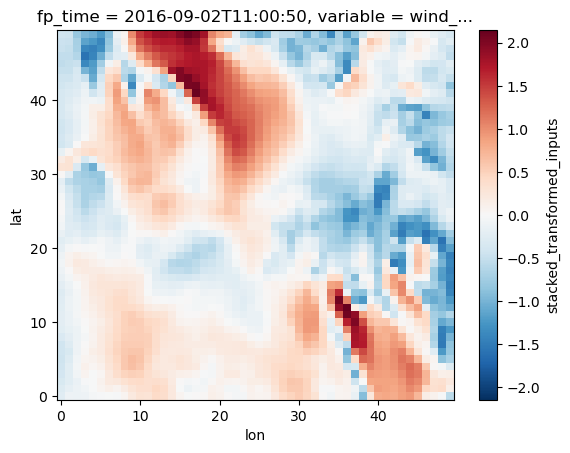

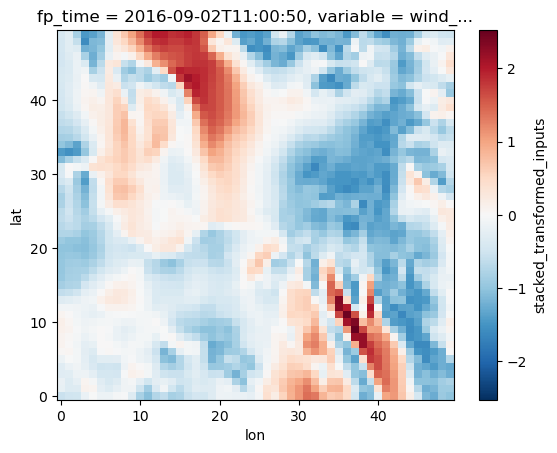

In [ ]:
# the inputs, and the scaled inputs, store the data as a stacked array, 
# stacked along the variable_name dimension with shape (variable_name, levels, delta_time)
# e.g. we can plot the x_wind at level 3 for a particular timepoint, at delta_time = 0 and at delta_time = 6 (below)
# it will take a bit to load, it's doing the calculation on the fly!
# the same data could be selected with test_inputs_scaled.sel(variable="wind_speed", level=3, delta_time=0) or test_inputs_scaled.sel(variable="wind_speed", level=3, delta_time=6)
test_inputs_scaled.sel(variable_name= ('wind_speed', 3, 0)).isel(fp_time=0).plot()
plt.show()
test_inputs_scaled.sel(variable_name= ('wind_speed', 3, 6)).isel(fp_time=0).plot()

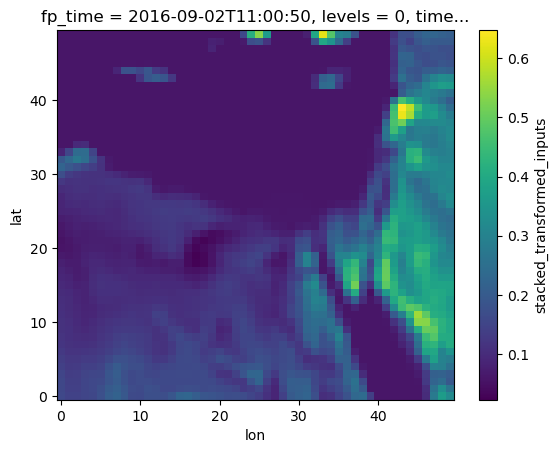

In [15]:
test_inputs_scaled.sel(variable = 'topog').isel(fp_time=0).plot()

In [ ]:
# we can also transform the footprints
# for example, apply a log and shift scaler, which is common for footprint data, to make the distribution more normal and easier to learn from
fpds = gates_datasets.FootprintDataset(data.fp_xr, scaler=gates_datasets.LogAndShiftMeanFpScaler, scaler_params={"minimum_oom": 6})
transformed_fps = fpds.fit_transform()

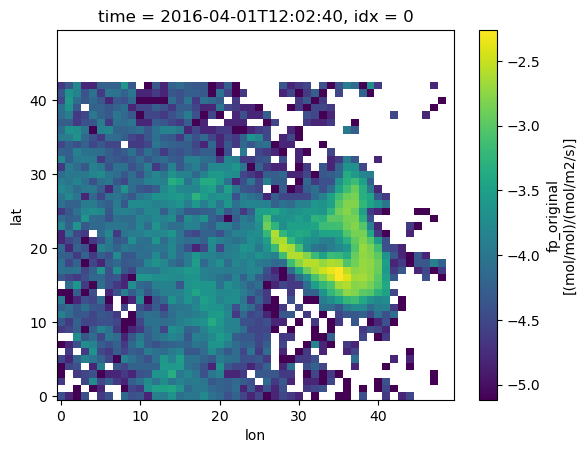

In [15]:
t_idx = 0
#t = transformed_fps.fp_transformed.isel(time=t_idx)
t = np.log10(transformed_fps.fp_original.isel(time=t_idx))
t.plot()

In [16]:
transformed_fps_test = fpds.transform(data_test.fp_xr)
# we can also inverse transform the footprints back to the original space if needed, e.g. for plotting or evaluation
inverse_transformed_fp = fpds.inverse_transform(transformed_fps_test.fp_transformed)

In [ ]:
# OR apply a log and shift scaler that doesn't use the mean and can be strictly non-negative
fpds = gates_datasets.FootprintDataset(data.fp_xr, scaler=gates_datasets.LogAndShiftFpScaler, scaler_params={"minimum_oom": 6})
transformed_fps = fpds.fit_transform()

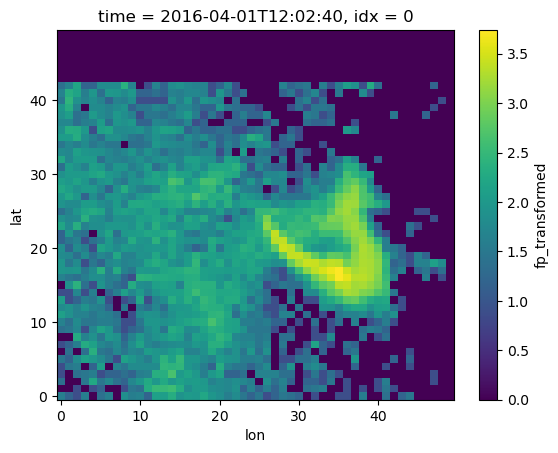

In [18]:
t = transformed_fps.fp_transformed.isel(time=0)
t.plot()

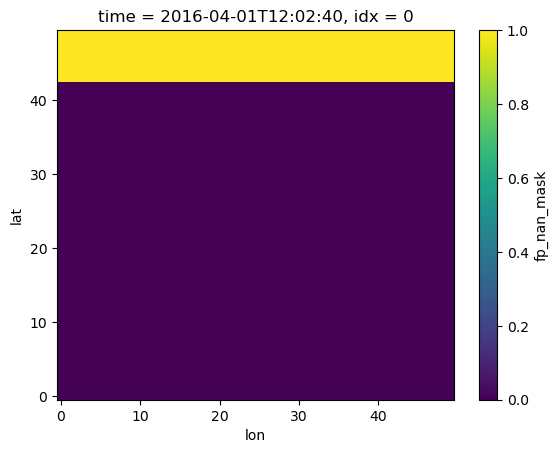

In [ ]:
# if we pass add_nan_mask=True to the FootprintDataset, it will also add a mask indicating where the original footprints had nans, which can be useful to calculate the loss function avoiding areas where the footprints are not valid
fpds = gates_datasets.FootprintDataset(data.fp_xr, scaler=gates_datasets.LogAndShiftFpScaler, scaler_params={"minimum_oom": 6}, add_nan_mask=True)
transformed_fps = fpds.fit_transform()
transformed_fps.fp_nan_mask.isel(time=0).plot()

### setting up an xbatcher

In [ ]:
## the dataloader is created from an inputs array (stacked along the variable_name coord) and a footprints array OR dataset, and will return batches of inputs and footprints for training the model. randomize=True will shuffle the data, which is usually recommended for training

# we use the following params so it runs quickly on a notebook - no parallel processes (num_workers=0) and no prefetching (prefetch_factor=None). prefetch_factor indicates the number of batches to load in the background following the current batch, to speed up training
dataloader_params={"prefetch_factor": None, "num_workers": 0}

# here, transformed_fps.fp_transformed is a DataArray, so the dataloader will return batches of inputs and footprints 
train_dataloader, fp_labels = gates_datasets.make_dataloader(inputs_scaled, transformed_fps.fp_transformed, batch_size=3, randomize=False, dataloader_params=dataloader_params)

In [26]:
train_features, train_footprints = next(iter(train_dataloader))
print(f"shape of train_features: {train_features.shape} \nshape of train_footprints: {train_footprints.shape} with labels {fp_labels}")

shape of train_features: torch.Size([3, 50, 50, 33]) 
shape of train_footprints: torch.Size([3, 50, 50]) with labels ['fp_transformed']


In [ ]:
# alternatively, we can pass a dataset (transformed_fps has variables fp_transformed, fp_original and fp_nan_mask) and the returned footprints will have as many dimensions as the dataset variables
train_dataloader, fp_labels = gates_datasets.make_dataloader(inputs_scaled, transformed_fps, batch_size=3, randomize=False, dataloader_params=dataloader_params)
train_features, train_footprints = next(iter(train_dataloader))
print(f"shape of train_features: {train_features.shape} \nshape of train_footprints: {train_footprints.shape} with labels {fp_labels}")

you passed a fps dataset with multiple variables: ['fp_transformed', 'fp_original', 'fp_nan_mask']. All variables will be returned in the dataloader along a new dimension. 
shape of train_features: torch.Size([3, 50, 50, 33]) 
shape of train_footprints: torch.Size([3, 50, 50, 3]) with labels ['fp_transformed', 'fp_original', 'fp_nan_mask']
